# Ejercicio Integrador — Rating, Sentimiento y Perfil de Viajero
 
Una cadena de hoteles quiere entender qué hace que una estadía sea buena o mala, más allá del promedio de estrellas. Tienen 340 reseñas de sus hoteles, con el texto completo de cada reseña y datos de quién la escribió. Se pide un análisis que combine el rating, el texto y el perfil del viajero para producir conclusiones accionables.
 
## Dataset
 
`reviews_hoteles.csv` — 340 filas, 8 columnas:
 
| Columna | Descripción |
|---|---|
| `fecha` | Fecha de la reseña |
| `hotel` | Nombre del hotel |
| `ciudad` | Ciudad donde está el hotel |
| `categoria_hotel` | Categoría oficial del hotel, en estrellas (1 a 5, fija por hotel) |
| `rating_usuario` | Puntuación que el huésped le dio a su estadía (1 a 5) |
| `review` | Texto de la reseña |
| `motivo_viaje` | Negocios, Familia, Pareja, Amigos o Solo |
| `procedencia` | País de origen del huésped |

## Consigna
 
1. **EDA sobre rating.** Explorar la distribución de `rating_usuario` y compararla contra `categoria_hotel`. ¿Los hoteles de más estrellas tienen, en promedio, mejor rating de usuario?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pysentimiento import create_analyzer 

df = pd.read_csv("reviews_hoteles.csv")

# esto lo hice al principio pero depsues con el total de la tabla es innecesario: 

# cat_hotel = df["rating_usuario"].value_counts().sort_index()

# print(f" total de reseñas:\n \n {cat_hotel}")

tabla_cat_reseña = pd.pivot_table(df, index=["rating_usuario"], columns="categoria_hotel", aggfunc="size", fill_value=0)

tabla_cat_reseña["total"] = tabla_cat_reseña.sum(axis=1)


print(f"\n Cantidad de reseñas en relación a categoria del hotel: \n \n {tabla_cat_reseña}")
 




 Cantidad de reseñas en relación a categoria del hotel: 
 
 categoria_hotel   2   3   4   5  total
rating_usuario                        
1                 2  18  13   6     39
2                 6  13  14  11     44
3                 5  28  19   8     60
4                12  46  42  19    119
5                10  33  24  11     78


In [11]:
analyzer = create_analyzer(task="sentiment", lang="es")

def textualizar ():
    list_of_tuples = list(df[["review"]].itertuples(index=False, name=None))#metodo pandas para pasar a tuplas 
    #https://www.slingacademy.com/article/pandas-converting-a-dataframe-to-a-list-of-tuples/
    # print(list_of_tuples)
    return list_of_tuples

reviews = textualizar()
resultados = pd.Series(reviews).apply(lambda review: analyzer.predict(review[0]).output)
# print(resultados)
df["Sentimientos"] = resultados
print(df["Sentimientos"].head(5))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

0    NEU
1    POS
2    NEG
3    NEG
4    POS
Name: Sentimientos, dtype: str


3. **Rating vs. sentimiento.** Convertir `rating_usuario` a una categoría comparable con el sentimiento detectado, y encontrar los casos donde no coinciden. Calcular qué porcentaje de las reseñas cae en cada caso.

In [12]:

"""
esto tambien lo habia hecho al principio pero depsues lo pasamos a limpio

def rating_convert(rating):
    if rating < 3:
        return "POS"
    elif rating > 3:
        return "NEG"
    elif rating == 3:
        return "NEU"
    else: return "ERROR"

df2["sentimiento"] = df2["rating_usuario"].apply(rating_convert)

print(df2["sentimiento"].head())"""

def categorizar_rating(rating):
    if rating >= 4:
        return "POS"
    elif rating == 3:
        return "NEU"
    else:
        return "NEG"
    
df["rating_categoria"] = df["rating_usuario"].apply(categorizar_rating)
# print(df["rating_categoria"])

df["coincide"] = df["Sentimientos"] == df["rating_categoria"] 
df["Sin_coincidencias"] = df["coincide"].apply(lambda x: "No" if x == False else "Si")
print(df["Sin_coincidencias"].value_counts())

no_coinciden = df[df["coincide"] == False]
print(no_coinciden)

porcentajes = df["coincide"].value_counts(normalize=True) * 100
print(porcentajes)


Sin_coincidencias
Si    301
No     39
Name: count, dtype: int64
          fecha                    hotel               ciudad  \
13   2025-10-06  Boutique Palermo Suites         Buenos Aires   
16   2025-10-06        Hostal Las Termas  Termas de Río Hondo   
23   2025-10-08         Hotel Costa Azul        Mar del Plata   
38   2025-10-15      Hotel Central Plaza              Córdoba   
41   2025-10-18           Posada del Sol                Salta   
79   2025-10-30       Resort Laguna Azul     Villa Carlos Paz   
85   2025-11-02         Hotel Costa Azul        Mar del Plata   
102  2025-11-08         Hotel Faro Viejo        Puerto Madryn   
115  2025-11-13       Resort Laguna Azul     Villa Carlos Paz   
117  2025-11-14       Resort Laguna Azul     Villa Carlos Paz   
121  2025-11-17          Hotel Río Claro              Mendoza   
122  2025-11-18          Hotel Río Claro              Mendoza   
125  2025-11-18         Hotel Faro Viejo        Puerto Madryn   
136  2025-11-21  Boutique 

4. **Segmentación por perfil.** Comparar rating y sentimiento según `motivo_viaje` y `procedencia`. ¿Hay diferencias entre cómo puntúan los viajeros de negocios y los de ocio?

0      Familia - Colombia - NEU - NEU
1         Familia - Chile - POS - POS
2         Pareja - España - NEG - NEG
3         Pareja - Brasil - NEG - NEG
4        Familia - México - POS - POS
                    ...              
335          Solo - Chile - POS - POS
336         Solo - Brasil - POS - POS
337      Familia - Brasil - NEG - NEG
338     Amigos - Colombia - POS - POS
339       Familia - Chile - POS - POS
Name: segmentacion, Length: 340, dtype: str
Sentimientos  NEG  NEU  POS
motivo_viaje               
Amigos         17   14   36
Familia        17   11   52
Negocios       13   10   42
Pareja         10    8   30
Solo           16   14   50
 Porcentajes: 
 Sentimientos        NEG        NEU        POS
motivo_viaje                                 
Amigos        25.373134  20.895522  53.731343
Familia       21.250000  13.750000  65.000000
Negocios      20.000000  15.384615  64.615385
Pareja        20.833333  16.666667  62.500000
Solo          20.000000  17.500000  62.500000


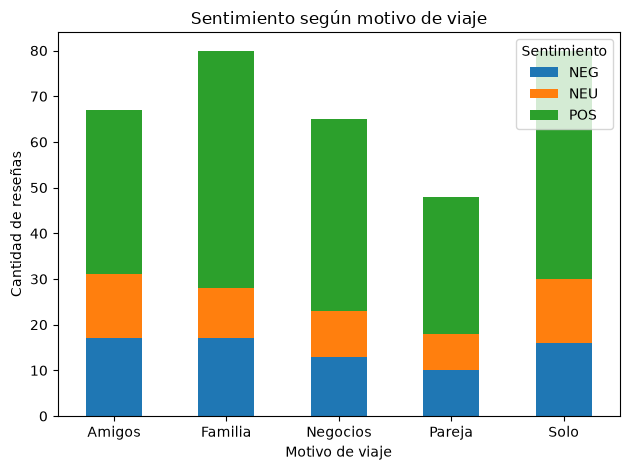

In [33]:
#Rating segun motivo de viaje y procedencia
df["segmentacion"] = df["motivo_viaje"] + " - " + df["procedencia"] + " - " + df["rating_categoria"] + " - " + df["Sentimientos"]
print(df["segmentacion"])

grafico = pd.crosstab(
    df["motivo_viaje"],
    df["Sentimientos"]
)

grafico_pct = grafico.div(grafico.sum(axis=1), axis=0) * 100
gradico_pct = grafico_pct.round()

print(grafico)
print(f" Porcentajes: \n {grafico_pct}")

grafico.plot(kind="bar", stacked=True)
plt.title("Sentimiento según motivo de viaje")
plt.xlabel("Motivo de viaje")
plt.ylabel("Cantidad de reseñas")
plt.xticks(rotation=0)
plt.legend(title="Sentimiento")
plt.tight_layout()
plt.show()


5. **Brecha categoría-experiencia.** Por hotel, calcular la diferencia entre `categoria_hotel` y el `rating_usuario` promedio. Identificar los hoteles con mayor brecha negativa.

Hoteles con mayor brecha negativa entre categoria y opinión huesped: 
 hotel
Resort Laguna Azul         1.772727
Gran Hotel Andes           1.606061
Cabañas del Bosque         0.696970
Hotel Río Claro            0.512821
Boutique Palermo Suites    0.475000
Name: diferencia_rating_categoria, dtype: float64


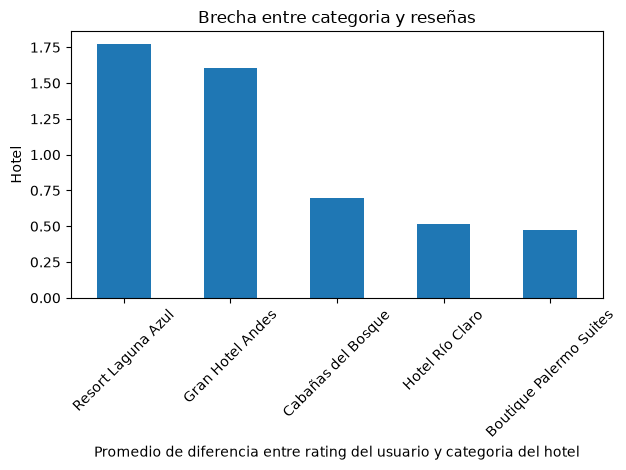

In [27]:
#Diferencia va a marcar a mayor puntaje, mayor brecha entre estrellas del hotel y las reseñas de manera negativa (hotel 5 estrellas con muchas reseñas de 3 va a estar mas cerca del 2). Cuanto mas se acerque a 0 mas pareja la relación, en caso que sea negativo el valor otorgado, hay mejor reseña que categoria del hotel.
df["diferencia_rating_categoria"] = df.categoria_hotel - df.rating_usuario

promedio_diferencia = df.groupby("hotel")["diferencia_rating_categoria"].mean()

hoteles_filtrados = promedio_diferencia[promedio_diferencia > 0].sort_values(ascending=False)

print(f"Hoteles con mayor brecha negativa entre categoria y opinión huesped: \n {hoteles_filtrados}")

#dejo el promedio en el df

df["promedio_diferencia"] = df.groupby("hotel")["diferencia_rating_categoria"].transform("mean")


hoteles_filtrados.plot(kind="bar")
plt.title("Brecha entre categoria y reseñas")
plt.xlabel("Promedio de diferencia entre rating del usuario y categoria del hotel")
plt.ylabel("Hotel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



6. **Visualización.** Al menos dos gráficos: uno que cruce rating y sentimiento, y otro que compare sentimiento entre segmentos de viajero.

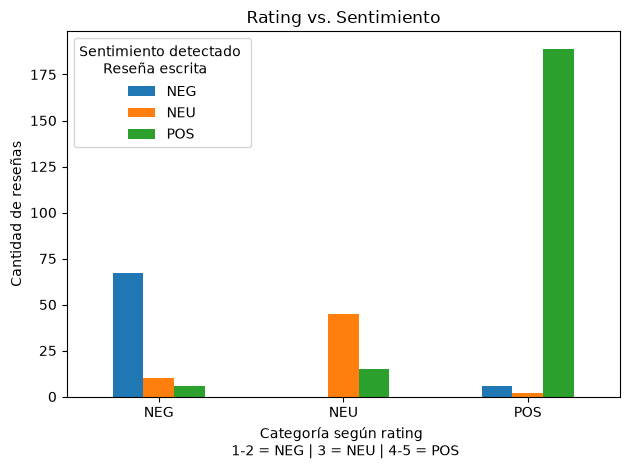

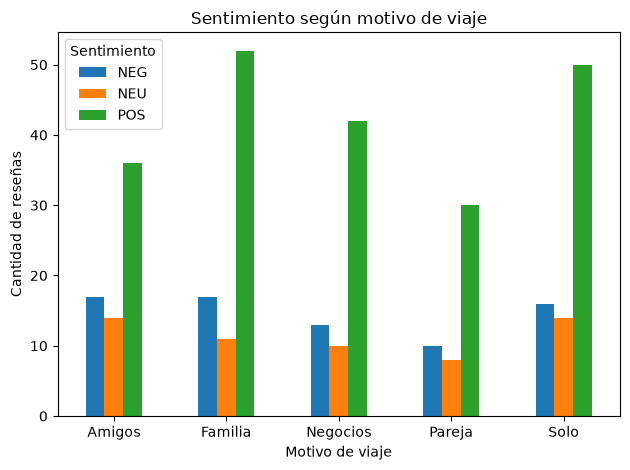

In [43]:
# Rating y sentimiento
grafico_rating_sentimiento = pd.crosstab(
    df["rating_categoria"],
    df["Sentimientos"]
)

grafico_rating_sentimiento.plot(kind="bar")

plt.title("Rating vs. Sentimiento")
plt.xlabel("Categoría según rating \n 1-2 = NEG | 3 = NEU | 4-5 = POS")
plt.ylabel("Cantidad de reseñas")
plt.xticks(rotation=0)
plt.legend(title="Sentimiento detectado \n      Reseña escrita")
plt.tight_layout()
plt.show()

grafico_segmentos = pd.crosstab(
    df["motivo_viaje"],
    df["Sentimientos"]
)

#Sentimiento entre segmentos de viajero
grafico_segmentos.plot(kind="bar")

plt.title("Sentimiento según motivo de viaje")
plt.xlabel("Motivo de viaje")
plt.ylabel("Cantidad de reseñas")
plt.xticks(rotation=0)
plt.legend(title="Sentimiento")
plt.tight_layout()
plt.show()

7. **Storytelling.** Con los resultados anteriores, escribir una conclusión de negocio de 3 a 5 oraciones dirigida a la cadena de hoteles. Debe basarse en los números encontrados, no en impresiones generales.

In [ ]:
# La categoria de hotel mas elegida segun la cantidad de reseñas de los usuarios es 4 estrellas, con un total de 119 reseñas, casi un 50% más que el segundo(5 estrellas-79 reseñas). 
# La fiabilidad de los datos del rating de los usuarios es de un 88%, con un 12% no coincidente con las reseñas escritas.
# Los viajes con amigos suelen tener una distribución de percepcion del consumidor más tendiente al neutro y negativo(25-21-54) en comparativa con el resto(20-15-63 promedio).
# Los hoteles con peor desempeño segun la relación entre su categoria y la percepcion del consumidor son Gran Hotel Andes y Resort Laguna Azul.

## Pistas
 
- Para el análisis de sentimiento, `pysentimiento` es una librería en Python con un modelo ya entrenado para español — no hace falta entrenar nada, se instala y se usa directo.
- `categoria_hotel` y `rating_usuario` son cosas distintas: una es fija por hotel, la otra varía por reseña. La consigna 5 depende de no confundirlas.
- Para "no coincide" en la consigna 3, primero hay que llevar el rating a la misma escala que devuelve el modelo de sentimiento (positivo / negativo / neutro).
- Conviene resolver la consigna 1 antes que la 2 — tener una idea de cómo se distribuye el rating ayuda a interpretar mejor los resultados del sentimiento después.